<a href="https://colab.research.google.com/github/Barrieaut/loan-default-prediction/blob/main/Assignment_15_Loan_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset size:
(850, 10)

Summary statistics:
              age          ed      employ     address      income     debtinc  \
count  850.000000  850.000000  850.000000  850.000000  850.000000  850.000000   
mean    35.029412    1.710588    8.565882    8.371765   46.675294   10.171647   
std      8.041432    0.927784    6.777884    6.895016   38.543054    6.719441   
min     20.000000    1.000000    0.000000    0.000000   13.000000    0.100000   
25%     29.000000    1.000000    3.000000    3.000000   24.000000    5.100000   
50%     34.000000    1.000000    7.000000    7.000000   35.000000    8.700000   
75%     41.000000    2.000000   13.000000   12.000000   55.750000   13.800000   
max     56.000000    5.000000   33.000000   34.000000  446.000000   41.300000   

         creddebt     othdebt     default      gender  
count  850.000000  850.000000  700.000000  850.000000  
mean     1.576805    3.078789    0.261429    0.508235  
std      2.125840    3.398803    0.439727    0.500227  
m

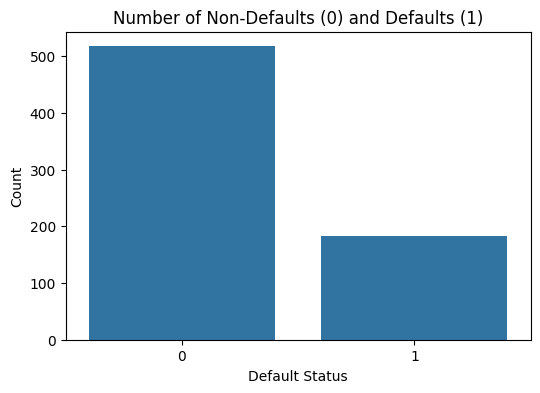

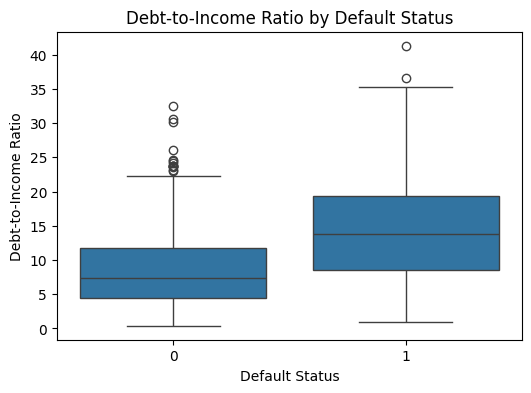


Feature engineering and scaling completed.

Accuracy Score:
0.8214285714285714

Confusion Matrix:
[[94  9]
 [16 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       103
           1       0.70      0.57      0.63        37

    accuracy                           0.82       140
   macro avg       0.78      0.74      0.75       140
weighted avg       0.81      0.82      0.82       140



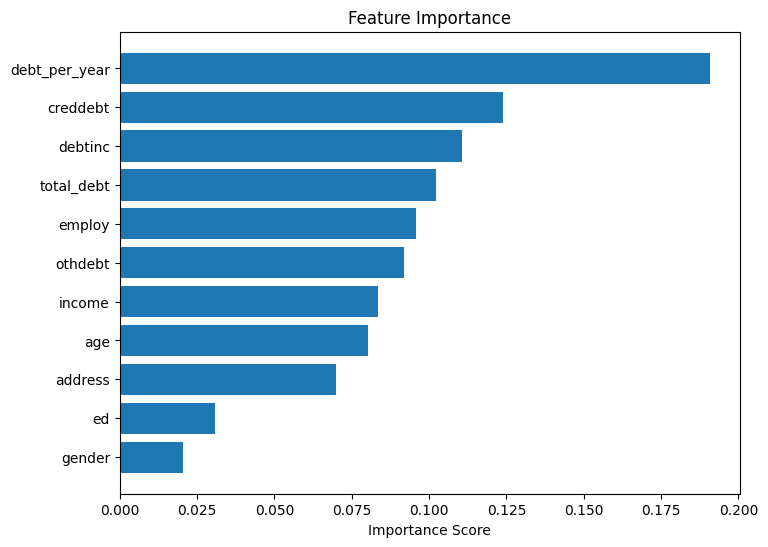

/tmp/ipykernel_9058/2928323080.py:118: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test_scaled, show=False)


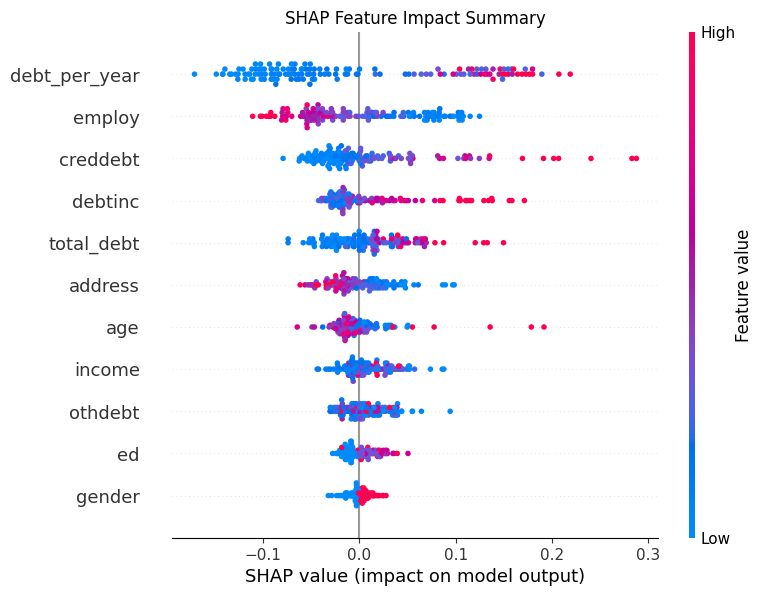


Fairness Metrics By Gender:
Female Accuracy: 0.86
Female Loan Approval Prediction Rate: 0.83
Male Accuracy: 0.78
Male Loan Approval Prediction Rate: 0.74


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import shap

# TASK 1: DATA ANALYSIS AND CLEANING

# 1. Load the data
df = pd.read_csv('bank-loan.csv')

# Add a simulated gender column for the fairness task (0 = Female, 1 = Male)
np.random.seed(42)
df['gender'] = np.random.choice([0, 1], size=len(df), p=[0.5, 0.5])

print("Dataset size:")
print(df.shape)

print("\nSummary statistics:")
print(df.describe())

# 2. Handle missing values
# Remove rows where the target 'default' is missing
df_clean = df.dropna(subset=['default']).copy()
df_clean['default'] = df_clean['default'].astype(int)

print("\nCleaned dataset size:")
print(df_clean.shape)

# 3. Visualizations
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df_clean)
plt.title('Number of Non-Defaults (0) and Defaults (1)')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='default', y='debtinc', data=df_clean)
plt.title('Debt-to-Income Ratio by Default Status')
plt.xlabel('Default Status')
plt.ylabel('Debt-to-Income Ratio')
plt.show()


# TASK 2: FEATURE ENGINEERING AND SCALING

# 1. Create new features
df_clean['total_debt'] = df_clean['creddebt'] + df_clean['othdebt']
df_clean['debt_per_year'] = df_clean['debtinc'] / (df_clean['employ'] + 1)

# 2. Separate features from the target variable
X = df_clean.drop(columns=['default'])
y = df_clean['default']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Save the gender column for the fairness analysis before scaling
gender_test = X_test['gender']

# 3. Scale numerical features
scaler = StandardScaler()
num_cols = ['age', 'ed', 'employ', 'address', 'income', 'debtinc', 'creddebt', 'othdebt', 'total_debt', 'debt_per_year']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print("\nFeature engineering and scaling completed.")


# TASK 3: MODEL BUILDING AND EVALUATION

# 1. Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Make predictions
y_pred = model.predict(X_test_scaled)

# 3. Display metrics
print("\nAccuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot feature importance
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()


# TASK 4: EXPLAINABILITY AND FAIRNESS ANALYSIS

# 1. SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure()
shap.summary_plot(shap_values[:, :, 1], X_test_scaled, show=False)
plt.title('SHAP Feature Impact Summary')
plt.show()

# 2. Fairness Analysis
fairness_df = pd.DataFrame({
    'gender': gender_test.values,
    'actual': y_test.values,
    'predicted': y_pred
})

print("\nFairness Metrics By Gender:")

# Female group (0)
female_group = fairness_df[fairness_df['gender'] == 0]
female_accuracy = accuracy_score(female_group['actual'], female_group['predicted'])
female_selection_rate = (female_group['predicted'] == 0).mean()
print(f"Female Accuracy: {female_accuracy:.2f}")
print(f"Female Loan Approval Prediction Rate: {female_selection_rate:.2f}")

# Male group (1)
male_group = fairness_df[fairness_df['gender'] == 1]
male_accuracy = accuracy_score(male_group['actual'], male_group['predicted'])
male_selection_rate = (male_group['predicted'] == 0).mean()
print(f"Male Accuracy: {male_accuracy:.2f}")
print(f"Male Loan Approval Prediction Rate: {male_selection_rate:.2f}")


# Task 5: Ethical Considerations Report

## 1. Fairness and Bias Mitigation Strategy
Machine learning models trained on historical financial data risk reproducing human biases. If historical lending decisions favored a specific group, the model will treat that bias as a correct pattern.

In this project, we checked fairness by analyzing accuracy and loan approval prediction rates across genders. If a demographic gap is found in a production environment, the bank should implement algorithmic debiasing methods. These include balancing the training dataset before training or adjusting decision cut-off thresholds to ensure equitable access to credit.

## 2. Privacy Protection Framework
Loan default predictive datasets contain sensitive personal data. To safeguard applicant privacy, all direct personal identifiers must be removed from the dataset before model development begins.

Data processing pipelines must comply with modern data privacy frameworks like GDPR or CCPA. For production systems, the bank should consider using data anonymization techniques or differential privacy. These methods inject controlled statistical noise into the training process, preventing individual customer profiles from being exposed.

## 3. Transparency and Explainability
Automated lending systems are often criticized for operating as untrainable black boxes. This creates compliance problems, as applicants have a right to know why a loan was denied.

We solved this problem by integrating SHAP (SHapley Additive exPlanations) values. SHAP provides transparency by calculating how much each financial feature contributes to the final prediction. This allows underwriting teams to give clear, defensible reasons for credit decisions, building trust with consumers and regulatory auditors.
